In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np

loc = Path.cwd()

print(loc)
json_file=[]
json_filer=[]
json_filea=[]
# ax = alexnet extra classes
json_fileax=[]

/home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare


In [2]:
imgNetF = loc / "resNet_data"

# Find and read all JSON files recursively
for file_path in imgNetF.rglob("*.json"):
    print(f"Found: {file_path}")
    json_filer.append(file_path)
        

imgNetA = loc / "alexnet_data"

# Find and read all JSON files recursively
for file_path in imgNetA.rglob("*.json"):
    print(f"Found: {file_path}")
    json_filea.append(file_path)
    
imgNetB = loc / "alexnet_1000_data"

for file_path in imgNetB.rglob("*.json"):
    print(f"Found: {file_path}")
    json_fileax.append(file_path)


Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/resNet_data/inat_resnet18_500_ptclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/resNet_data/inat_resnet50_500_ptclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/resNet_data/inat_resnet18_500_npclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/resNet_data/inat_resnet50_500_npclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/alexnet_data/inat_alexnet_500_ptclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/alexnet_data/inat_alexnet_500_npclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/alexnet_1000_data/inat_alexnet_1000_npclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP

In [3]:
json_file = json_filea+json_filer+json_fileax
json_data=[]
# Find and read all JSON files recursively
for file_path in json_file:    
    print(file_path.name)
    try:
        # read_text() reads content; json.loads() parses it
        data = json.loads(file_path.read_text(encoding="utf-8"))
        print(data)
        json_data.append(data)
        # Process your data here
    except json.JSONDecodeError:
        print(f"Error: {file_path.name} is not a valid JSON file.")

model_name={"inat_resnet18_500_ptclasses_imagenet_history.json":"ResNet18 pretrained",
            "inat_resnet50_500_ptclasses_imagenet_history.json":"ResNet50 pretrained",
            "inat_resnet18_500_npclasses_imagenet_history.json":"ResNet18 random init",
            "inat_resnet50_500_npclasses_imagenet_history.json":"ResNet50 random init",
            "inat_alexnet_500_ptclasses_imagenet_history.json": "AlexNet pretrained",
            "inat_alexnet_500_npclasses_imagenet_history.json": "AlexNet random init",
            "inat_alexnet_1000_ptclasses_imagenet_history.json": "AlexNet pretrained (1000-class)",
            "inat_alexnet_1000_npclasses_imagenet_history.json": "AlexNet random init (1000-class)",
            }

# json_file = json_filea +json_filer

print(len(json_file),len(model_name.keys()))
assert len(model_name.keys())==(len(json_file))

inat_alexnet_500_ptclasses_imagenet_history.json
{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50], 'train_loss': [5.236420728302002, 3.5333145462036133, 2.991006613922119, 2.625647515106201, 2.3531278648376466, 2.131268230056763, 1.9435373050689697, 1.7921272819519043, 1.6727814624786377, 1.5737687314987183, 1.4991703037261963, 1.436189902114868, 1.3945408618927002, 1.3589836793899537, 1.328423525619507, 1.3044975872039795, 1.2824734981536865, 1.2627574264526367, 1.2506358600616454, 1.232998916053772, 1.2241215915679933, 1.2133654010772705, 1.2059254434585571, 1.1964510906219483, 1.1883177156448363, 1.1816627115249634, 1.1783520769119262, 1.1716820529937744, 1.1503686241149902, 1.1404063364028931, 1.1349419734954833, 1.131625089454651, 1.12777545337677, 1.1237346996307374, 1.1234055389404296, 1.1179552967071533, 1.1199104326248168, 1.1

In [4]:
print("json_data:", len(json_data))
print("json_file:", len(json_file))
print("model_name:", len(model_name))

json_data: 8
json_file: 8
model_name: 8


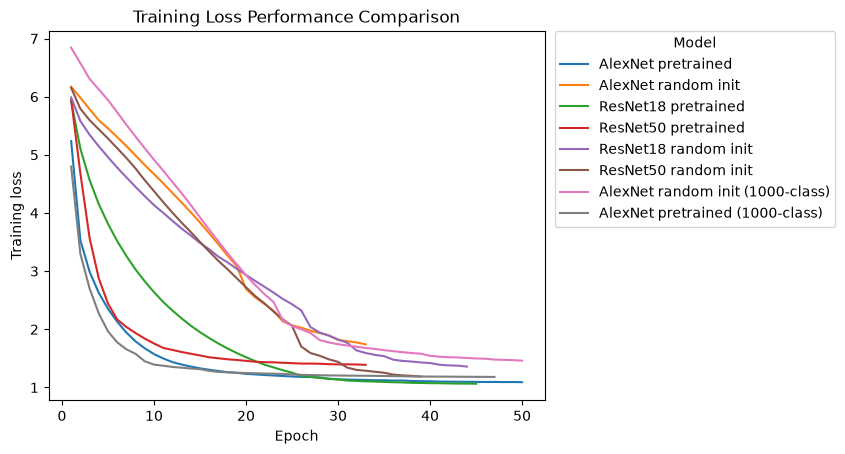

In [5]:
# train loss

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss Performance Comparison")
plt.savefig("./training_loss_compare.jpg", dpi=300, bbox_inches='tight')
plt.show()


# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

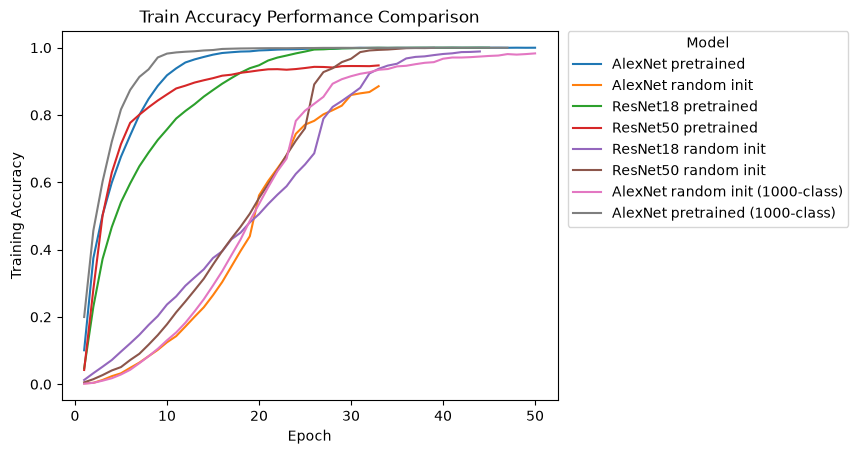

In [6]:
# train acc

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Train Accuracy Performance Comparison")
plt.savefig("./training_acc_compare.jpg", dpi=300, bbox_inches='tight')
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

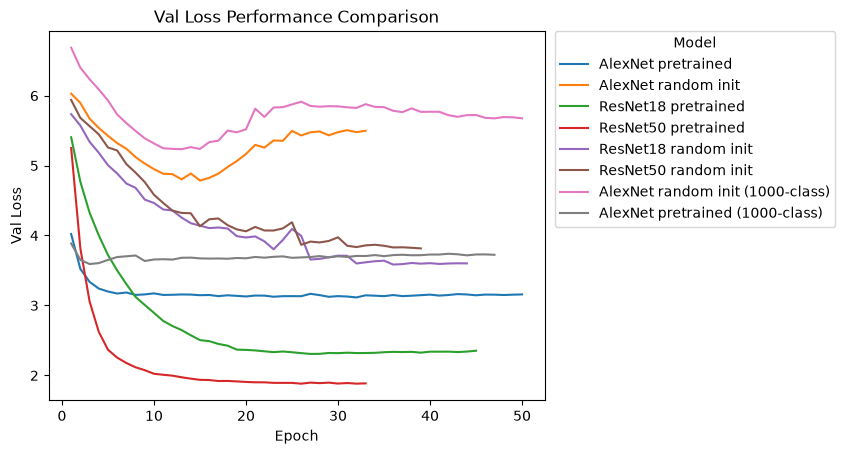

In [7]:
# val loss


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Val Loss Performance Comparison")
plt.savefig("./val_loss_compare.jpg", dpi=300, bbox_inches='tight')
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

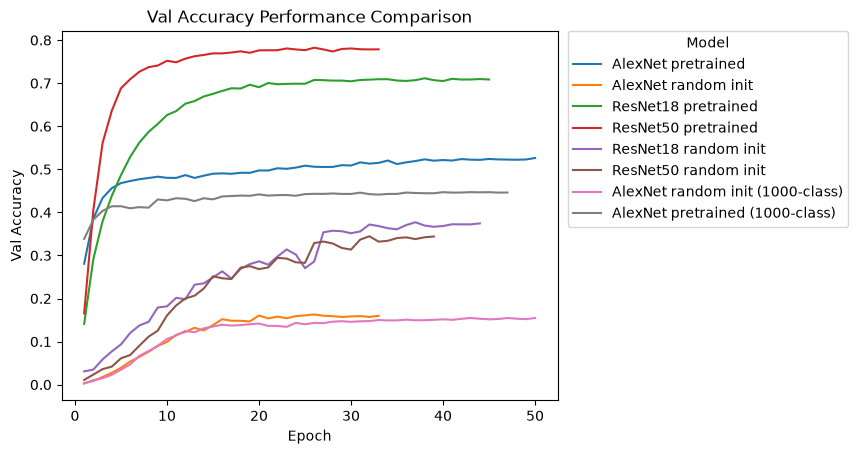

In [8]:
# val acc


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("Val Accuracy Performance Comparison")
plt.savefig("./val_acc_compare.jpg", dpi=300, bbox_inches='tight')
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

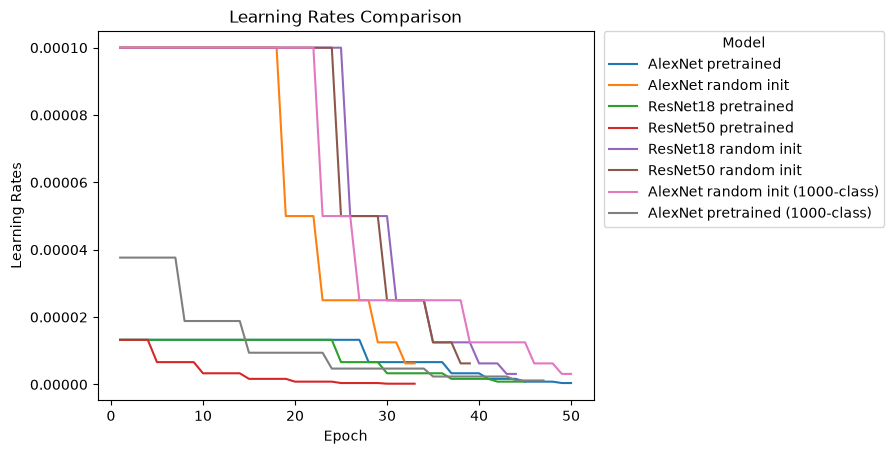

In [9]:
# learning rate

for dt in range(len(json_data)):
    if type(json_data[dt]['learning_rates'][0]) == list:
        row_averages = [sum(row) / len(row) for row in json_data[dt]['learning_rates']]
        plt.plot(json_data[dt]['epoch'], row_averages, label=model_name[json_file[dt].name], linestyle="-")

    else:
        plt.plot(json_data[dt]['epoch'], json_data[dt]['learning_rates'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("Learning Rates")
plt.title("Learning Rates Comparison")
plt.savefig("./lr_compare.jpg", dpi=300, bbox_inches='tight')
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib